# <center>Regularization and model selection</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: fundamentals of research in python</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Say why an unregularized least-squares fit fails when regressors are many or collinear, in terms of the conditioning met in `fd08` and `fd09`.

* Derive the **ridge** estimator, and read its action in the singular-value basis as shrinkage that is heaviest where the data are least informative.

* **Recognize the penalty $\lambda$ as a Lagrange multiplier** on a norm budget: verify numerically that the penalized and constrained problems have the same solution and that $dV/d\tau = -\lambda$.

* Write the **KKT conditions** of the lasso, derive the soft-thresholding operator from them, and implement **coordinate descent** from scratch.

* Read lasso sparsity as **complementary slackness**: the same $0\le\rho\perp\mu\ge0$ that decided which pairs were matched in `fd09` §6.

* Choose $\lambda$ by **cross-validation** implemented from scratch, and apply the one-standard-error rule.

* Recognize why inference *after* selection is not valid, and demonstrate the failure by simulation.

### References

**[HTF]** Hastie, T., Tibshirani, R., and Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer, Chapter 3: ridge, lasso, and the SVD view of shrinkage.

**[T]** Tibshirani, R. (1996). "Regression Shrinkage and Selection via the Lasso." *JRSS B* 58(1), 267–288.

**[FHT]** Friedman, J., Hastie, T., and Tibshirani, R. (2010). "Regularization Paths for Generalized Linear Models via Coordinate Descent." *Journal of Statistical Software* 33(1): the algorithm of §5.

**[BCH]** Belloni, A., Chernozhukov, V., and Hansen, C. (2014). "Inference on Treatment Effects after Selection among High-Dimensional Controls." *Review of Economic Studies* 81(2), 608–650: the problem raised in §9 and Exercise 5.

**[BV]** Boyd, S. and Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press, Chapters 4–5: the duality used throughout.

**[G]** Galichon, A. (2016). *Optimal Transport Methods in Economics*. Princeton University Press: entropic regularization in `ot04` is the same device applied to a transport problem.

## 1. Motivation

`fd08` §11 fitted a linear model by solving the normal equations, and `fd09` warned that a badly conditioned $X^\top X$ makes that solve unreliable. This lecture is about what to do when the problem is not merely badly conditioned but genuinely underdetermined, when there are many regressors relative to observations, or when regressors are strongly collinear, so that many different $\beta$ fit the data almost equally well.

The remedy is to add a term that expresses a preference among those near-equivalent fits:

$$
\min_\beta\ \underbrace{\tfrac{1}{2N}\lVert y - X\beta\rVert_2^2}_{\text{fit}} \;+\; \lambda\,\underbrace{P(\beta)}_{\text{penalty}},
\qquad
P(\beta) = \begin{cases}\lVert\beta\rVert_2^2 & \text{ridge}\\ \lVert\beta\rVert_1 & \text{lasso.}\end{cases} \tag{1.1}
$$

The lecture's claim, and the reason it closes the scientific-computing block, is that **$\lambda$ is not a tuning knob bolted onto a loss function. It is a Lagrange multiplier**, and everything distinctive about these estimators, that ridge shrinks but never zeroes, that lasso produces exact zeros, that the solution path bends where it does, follows from the KKT conditions of a constrained problem.

That places this lecture at the end of an argument the block has been making since `fd08`:

| | constraint | multiplier | reads as |
|---|---|---|---|
| `fd08` §13 | $A\mu = z$, assembled | $u_x, v_y$ (not yet solved) |: |
| `fd09` §6 | margins of a transport problem | $u_x, v_y$ from `linprog` | wages and firm rents |
| `fd10` §5 | $v_i = f_i(v_{\mathrm{pa}(i)})$ | $\bar v_i$ from a tape | gradient components |
| **`fd11`** | $\lVert\beta\rVert \le \tau$ | $\lambda$ | **the price of model complexity** |

Same object, four readings.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

rng = np.random.default_rng(8)

N, K, K_true = 100, 50, 5
X_n_k = rng.normal(size=(N, K))
X_n_k = (X_n_k - X_n_k.mean(axis=0)) / X_n_k.std(axis=0)      # standardized, as in fd08 Ex 2

beta_true_k = np.zeros(K)
beta_true_k[:K_true] = np.array([3.0, -2.0, 1.5, 2.5, -1.0])   # only 5 of 50 matter
y_n = X_n_k @ beta_true_k + rng.normal(scale=1.0, size=N)
y_n = y_n - y_n.mean()

beta_ols_k = np.linalg.solve(X_n_k.T @ X_n_k, X_n_k.T @ y_n)

print(f"N = {N} observations, K = {K} regressors, {K_true} of them truly nonzero")
print(f"condition number of X'X : {np.linalg.cond(X_n_k.T @ X_n_k):,.0f}")
print(f"\nOLS on the 45 TRUE ZEROS: mean |coefficient| = "
      f"{np.abs(beta_ols_k[K_true:]).mean():.4f}, max = {np.abs(beta_ols_k[K_true:]).max():.4f}")
print(f"OLS root mean squared error over all K: "
      f"{np.sqrt(((beta_ols_k - beta_true_k) ** 2).mean()):.4f}")
print(f"exact zeros produced by OLS: {int((beta_ols_k == 0).sum())} of {K - K_true}")

N = 100 observations, K = 50 regressors, 5 of them truly nonzero
condition number of X'X : 26

OLS on the 45 TRUE ZEROS: mean |coefficient| = 0.0984, max = 0.2866
OLS root mean squared error over all K: 0.1276
exact zeros produced by OLS: 0 of 45


With $K = 50$ regressors and $N = 100$ observations, ordinary least squares assigns a *nonzero* coefficient to every one of the 45 regressors that have no effect at all: some of them sizeable. It cannot do otherwise: the normal equations have a unique solution and nothing in them expresses a preference for simplicity.

**Note the condition number: about 26.** This design is *not* ill-conditioned: the regressors are independent and standardized, so the numerical difficulties of `fd08` §9 and `fd09` §3 do not arise, and `np.linalg.solve` returns the OLS estimate to machine precision. The problem here is **statistical, not numerical**. OLS is unbiased; it is simply *noisy*, because 50 parameters are being estimated from 100 observations, and it has no way to express the belief that most of them are zero.

That distinction is worth holding onto, because the two motivations for regularization are often run together. Collinearity is one reason to regularize, and it is the one ridge addresses most directly through the shrinkage of §2. Sparsity is a different reason, and it is the one the lasso addresses. Both are situations where the data alone do not pick out a fit, and the penalty supplies the missing preference.

## 2. Ridge: the closed form, and shrinkage in the singular-value basis

For $P(\beta) = \lVert\beta\rVert_2^2$ the objective in (1.1) is smooth and quadratic, so setting the gradient to zero gives a closed form:

$$
\hat\beta_\lambda \;=\; \bigl(X^\top X + \lambda N \mathbb{I}\bigr)^{-1} X^\top y . \tag{2.1}
$$

(The $N$ appears because the fit term in (1.1) is a *mean*; dropping it is the most common reason a hand-rolled ridge disagrees with a library's, as `fd10`, Exercise 5 noted.)

The formula is easy; what it *does* is better seen through the singular value decomposition $X = UDV^\top$ of `fd08` §9. Substituting,

$$
X\hat\beta_\lambda \;=\; \sum_{j} u_j\,\frac{d_j^2}{d_j^2 + \lambda N}\,u_j^\top y . \tag{2.2}
$$

Ridge leaves the singular *directions* alone and multiplies the $j$-th one by $d_j^2/(d_j^2+\lambda N) \in (0,1)$. Directions with large $d_j$, those the data pin down well, pass through almost unchanged; directions with small $d_j$, the poorly determined ones, which is exactly where an unregularized fit goes wrong, are shrunk hard.

**So ridge is not uniform shrinkage.** It is shrinkage concentrated where the data are least informative, which is why it stabilizes an ill-conditioned problem rather than merely biasing it.

In [2]:
def ridge_closed(X_n_k, y_n, lam):
    N, K = X_n_k.shape
    return np.linalg.solve(X_n_k.T @ X_n_k + lam * N * np.eye(K), X_n_k.T @ y_n)

U_n_j, d_j, Vt_j_k = np.linalg.svd(X_n_k, full_matrices=False)
lam = 0.05

beta_ridge_k = ridge_closed(X_n_k, y_n, lam)
beta_svd_k = Vt_j_k.T @ ((d_j / (d_j ** 2 + lam * N)) * (U_n_j.T @ y_n))

gap = np.abs(beta_ridge_k - beta_svd_k).max()
print(f"max |normal equations - SVD form| = {gap:.2e}   (tolerance 1e-10)")
assert gap < 1e-10

shrink_j = d_j ** 2 / (d_j ** 2 + lam * N)
print(f"\nsingular values run from {d_j.min():.2f} to {d_j.max():.2f}")
print(f"{'direction':>10}{'d_j':>10}{'shrinkage factor':>20}")
print("-" * 40)
for j in (0, 1, K // 2, K - 2, K - 1):
    print(f"{j:>10}{d_j[j]:>10.3f}{shrink_j[j]:>20.4f}")
print("-" * 40)
print(f"effective degrees of freedom = sum of factors = {shrink_j.sum():.2f}  (K = {K})")
assert np.all(np.diff(shrink_j) <= 1e-12)
print("check passed: shrinkage is monotone -- weakest directions shrink most.")

max |normal equations - SVD form| = 2.80e-15   (tolerance 1e-10)

singular values run from 3.28 to 16.55
 direction       d_j    shrinkage factor
----------------------------------------
         0    16.551              0.9821
         1    15.900              0.9806
        25     9.252              0.9448
        48     3.483              0.7082
        49     3.275              0.6821
----------------------------------------
effective degrees of freedom = sum of factors = 45.72  (K = 50)
check passed: shrinkage is monotone -- weakest directions shrink most.


The last line is worth a name. The sum of the shrinkage factors,

$$
\mathrm{df}(\lambda) \;=\; \sum_j \frac{d_j^2}{d_j^2+\lambda N},
$$

is the **effective degrees of freedom** of the ridge fit: it equals $K$ at $\lambda = 0$ and falls to $0$ as $\lambda\to\infty$. It is the honest measure of how many parameters the fit is really using: a continuous count, in contrast to the integer count of an unpenalized regression. Exercise 2 pursues it.

## 3. The penalty is a multiplier

Now the claim at the centre of the lecture. Consider the **constrained** problem

$$
V(\tau) \;=\; \min_\beta\ \tfrac{1}{2N}\lVert y - X\beta\rVert_2^2
\quad\text{subject to}\quad
P(\beta) \le \tau, \tag{3.1}
$$

which says: fit as well as possible, using no more than $\tau$ of *model complexity*. Its Lagrangian is

$$
\mathcal{L}(\beta,\lambda) \;=\; \tfrac{1}{2N}\lVert y-X\beta\rVert_2^2 + \lambda\bigl(P(\beta)-\tau\bigr),
$$

and minimizing over $\beta$ at fixed $\lambda$ gives back exactly the **penalized** problem (1.1), since the constant $-\lambda\tau$ does not affect the argmin. The two problems are Lagrangian duals of one another: for every budget $\tau$ there is a penalty $\lambda(\tau)$ giving the same solution, and conversely.

By the envelope theorem: `fd09` §4, `fd10` §5, and by now a familiar tool -

$$
\frac{dV}{d\tau} \;=\; -\lambda . \tag{3.2}
$$

**$\lambda$ is the shadow price of model complexity**: the rate at which fit improves as the complexity budget is relaxed. That is what makes it an economic object rather than a knob, and it is what we verify now: by solving (3.1) directly and differencing.

One implementation note that is itself instructive. The constraint $\lVert\beta\rVert_1\le\tau$ is *not smooth*, and `SLSQP` handles it badly. The standard remedy is to split $\beta = \beta^+ - \beta^-$ with $\beta^\pm \ge 0$, whereupon $\lVert\beta\rVert_1 = \sum_k(\beta^+_k+\beta^-_k)$ is **linear**: the same move that turns an absolute value into a linear program, as in `lp06`'s treatment of quantile regression.

In [3]:
def lasso_penalized(X_n_k, y_n, lam, start_k=None, n_sweeps=1000, tol=1e-12):
    """Coordinate descent on (1/2N)||y - X b||^2 + lam ||b||_1. Derived in section 5.

    start_k warm-starts from a previous solution, which is what makes computing a
    whole path cheap: neighbouring lambdas have nearly the same solution.
    """
    N, K = X_n_k.shape
    beta_k = np.zeros(K) if start_k is None else start_k.copy()
    col_k = (X_n_k ** 2).sum(axis=0) / N
    residual_n = y_n - X_n_k @ beta_k
    for sweep in range(n_sweeps):
        change = 0.0
        for k in range(K):
            if beta_k[k] != 0.0:
                residual_n = residual_n + X_n_k[:, k] * beta_k[k]
            rho = X_n_k[:, k] @ residual_n / N
            new = np.sign(rho) * max(abs(rho) - lam, 0.0) / col_k[k]
            if new != 0.0:
                residual_n = residual_n - X_n_k[:, k] * new
            change = max(change, abs(new - beta_k[k]))
            beta_k[k] = new
        if change < tol:
            return beta_k, sweep + 1
    return beta_k, n_sweeps

def lasso_constrained(X_n_k, y_n, tau, start_k=None):
    """Solve (3.1) for the l1 ball, via the smooth split b = bp - bm."""
    N, K = X_n_k.shape
    objective = lambda z: ((y_n - X_n_k @ (z[:K] - z[K:])) ** 2).sum() / (2 * N)
    z0 = (np.zeros(2 * K) if start_k is None
          else np.concatenate([np.maximum(start_k, 0), np.maximum(-start_k, 0)]))
    res = optimize.minimize(objective, z0, method="SLSQP", bounds=[(0, None)] * (2 * K),
                            constraints=[{"type": "ineq", "fun": lambda z: tau - z.sum()}],
                            options={"maxiter": 500, "ftol": 1e-12})
    assert res.success, res.message
    return res.fun, res.x[:K] - res.x[K:]

lam = 0.10
beta_pen_k, sweeps = lasso_penalized(X_n_k, y_n, lam)
tau = np.abs(beta_pen_k).sum()
value, beta_con_k = lasso_constrained(X_n_k, y_n, tau, start_k=beta_pen_k)

print(f"penalized (lambda = {lam}): converged in {sweeps} sweeps, ||beta||_1 = {tau:.6f}")
print(f"constrained (tau = {tau:.6f}): ||beta||_1 = {np.abs(beta_con_k).sum():.6f}")
gap = np.abs(beta_pen_k - beta_con_k).max()
print(f"\nmax |penalized - constrained| = {gap:.2e}   (tolerance 1e-5)")
assert gap < 1e-5
print("check passed: the two problems have the same solution.")

penalized (lambda = 0.1): converged in 25 sweeps, ||beta||_1 = 9.677783
constrained (tau = 9.677783): ||beta||_1 = 9.677783

max |penalized - constrained| = 0.00e+00   (tolerance 1e-5)
check passed: the two problems have the same solution.


In [4]:
# and the multiplier: dV/dtau must equal -lambda
h = 1e-4
V_plus, _ = lasso_constrained(X_n_k, y_n, tau + h, start_k=beta_pen_k)
V_minus, _ = lasso_constrained(X_n_k, y_n, tau - h, start_k=beta_pen_k)
dV_dtau = (V_plus - V_minus) / (2 * h)

print(f"dV/dtau by finite difference = {dV_dtau:+.9f}")
print(f"-lambda                      = {-lam:+.9f}")
gap = abs(dV_dtau + lam)
print(f"gap = {gap:.2e}   (tolerance 1e-5)")
assert gap < 1e-5
print("\ncheck passed: lambda is the shadow price of the complexity budget.")

dV/dtau by finite difference = -0.100000000
-lambda                      = -0.100000000
gap = 2.52e-11   (tolerance 1e-5)

check passed: lambda is the shadow price of the complexity budget.


Relaxing the budget by one unit buys exactly $\lambda$ of fit. The number reported by a cross-validation routine as "the best alpha" is therefore a price, and it can be read as one: a large $\lambda$ says complexity is expensive here, the data do not support much of it, and a small $\lambda$ says the opposite.

The same device, under the same logic, appears elsewhere in the masterclass series. In `ot04` an entropic penalty $\varepsilon\sum\mu_{xy}\log\mu_{xy}$ is added to the transport problem of `fd09` §6; $\varepsilon$ is the multiplier on an entropy budget, it makes the problem strictly convex and solvable by Sinkhorn's algorithm, and letting $\varepsilon\to0$ recovers the unregularized optimum. Regularization is not a statistical trick: it is a general method for turning an ill-posed problem into a well-posed one, and the penalty is always a price.

## 4. Lasso: the KKT conditions, and soft-thresholding

Ridge has a closed form because its penalty is differentiable. The lasso's is not: $\lvert\beta_k\rvert$ has a kink at zero, and that kink is precisely what produces exact zeros.

Write the objective as $L(\beta) = \frac{1}{2N}\lVert y-X\beta\rVert^2 + \lambda\lVert\beta\rVert_1$. At a minimum, $0$ must lie in the subdifferential, which coordinate by coordinate reads

$$
-\frac1N x_k^\top\bigl(y - X\beta\bigr) + \lambda s_k \;=\; 0,
\qquad
s_k \in \begin{cases}\{\operatorname{sign}\beta_k\} & \beta_k \neq 0\\ [-1,1] & \beta_k = 0 .\end{cases} \tag{4.1}
$$

Writing $r = y - X\beta$ for the residual, (4.1) says

$$
\boxed{\ \Bigl\lvert \tfrac1N x_k^\top r \Bigr\rvert \;\le\; \lambda \ \ \text{for every } k,
\qquad\text{with equality whenever } \beta_k \neq 0 .\ } \tag{4.2}
$$

**That is a complementary slackness condition**, and §6 reads it as one. First, the algorithm it implies.

**Soft-thresholding.** Consider the one-dimensional problem $\min_b \tfrac12(z-b)^2 + \lambda\lvert b\rvert$. If $b>0$ the derivative is $b - z + \lambda = 0$, so $b = z-\lambda$, which is positive only when $z>\lambda$; symmetrically $b = z+\lambda$ when $z<-\lambda$; and otherwise $b=0$, which is optimal exactly when $\lvert z\rvert\le\lambda$. Collecting,

$$
S(z,\lambda) \;=\; \operatorname{sign}(z)\,\max\bigl(\lvert z\rvert-\lambda,\ 0\bigr). \tag{4.3}
$$

This is the **soft-thresholding operator**: it moves $z$ toward zero by $\lambda$ and *clamps it to exactly zero* once $\lvert z\rvert$ falls below $\lambda$. Ridge, by contrast, multiplies by a factor strictly between 0 and 1 and therefore never reaches zero. The entire difference between the two estimators is visible in this one picture.

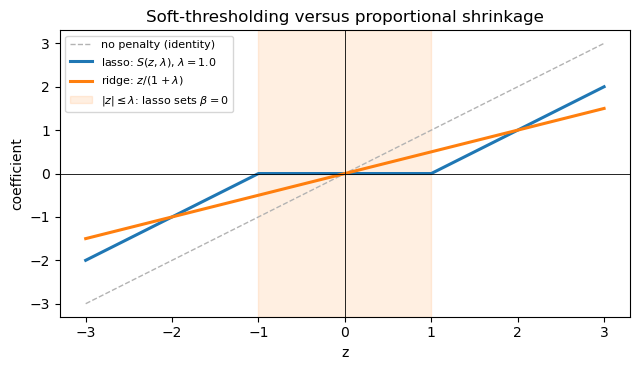

z =  -2.5:  formula -1.500000000   direct minimization -1.499999978   gap 2.2e-08
z =  -0.4:  formula -0.000000000   direct minimization -0.000000000   gap 7.8e-14
z =   0.0:  formula +0.000000000   direct minimization +0.000000000   gap 4.4e-16
z =   0.7:  formula +0.000000000   direct minimization +0.000000000   gap 2.4e-13
z =   2.2:  formula +1.200000000   direct minimization +1.199999982   gap 1.8e-08

check passed: (4.3) solves the one-dimensional problem.


In [5]:
soft_threshold = lambda z, t: np.sign(z) * np.maximum(np.abs(z) - t, 0.0)

z_p = np.linspace(-3, 3, 601)
lam_demo = 1.0

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(z_p, z_p, "0.7", lw=1, ls="--", label="no penalty (identity)")
ax.plot(z_p, soft_threshold(z_p, lam_demo), lw=2.2, label=rf"lasso: $S(z,\lambda)$, $\lambda={lam_demo}$")
ax.plot(z_p, z_p / (1 + lam_demo), lw=2.2, label=rf"ridge: $z/(1+\lambda)$")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.axvspan(-lam_demo, lam_demo, color="C1", alpha=0.12, label=r"$|z|\leq\lambda$: lasso sets $\beta=0$")
ax.set_xlabel("z"); ax.set_ylabel("coefficient")
ax.set_title("Soft-thresholding versus proportional shrinkage")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# verify (4.3) against a direct 1-D minimization
for z in (-2.5, -0.4, 0.0, 0.7, 2.2):
    direct = optimize.minimize_scalar(lambda b: 0.5 * (z - b) ** 2 + lam_demo * abs(b),
                                      bounds=(-5, 5), method="bounded",
                                      options={"xatol": 1e-12}).x
    formula = soft_threshold(z, lam_demo)
    print(f"z = {z:>5.1f}:  formula {formula:+.9f}   direct minimization {direct:+.9f}"
          f"   gap {abs(formula - direct):.1e}")
    assert abs(formula - direct) < 1e-5
print("\ncheck passed: (4.3) solves the one-dimensional problem.")

## 5. Coordinate descent, from scratch

Soft-thresholding solves the one-coordinate problem exactly, and that is enough: **cycle through the coordinates, optimizing each in turn with the others held fixed.** For coordinate $k$, write the partial residual $r^{(-k)} = y - \sum_{j\neq k} x_j\beta_j$; the objective in $\beta_k$ alone is a one-dimensional problem of exactly the form (4.3), so

$$
\beta_k \;\leftarrow\; \frac{S\!\left(\tfrac1N x_k^\top r^{(-k)},\ \lambda\right)}{\tfrac1N\lVert x_k\rVert^2} . \tag{5.1}
$$

Coordinate descent converges for this objective because the non-smooth part $\lambda\lVert\beta\rVert_1$ is *separable* across coordinates: a condition that fails, for instance, for a penalty like $\lVert\beta\rVert_2$, where cycling can stall away from the optimum. It is the algorithm behind `glmnet` and behind scikit-learn's `Lasso`, and it is a dozen lines.

The implementation is the `lasso_penalized` written in §3. We now check it against the library.

In [6]:
from sklearn.linear_model import Lasso, Ridge

lam = 0.10
beta_ours_k, sweeps = lasso_penalized(X_n_k, y_n, lam)

sk_lasso = Lasso(alpha=lam, fit_intercept=False, max_iter=200_000, tol=1e-14)
sk_lasso.fit(X_n_k, y_n)

gap = np.abs(beta_ours_k - sk_lasso.coef_).max()
print(f"our coordinate descent : {sweeps} sweeps, {int((beta_ours_k != 0).sum())} nonzeros")
print(f"sklearn Lasso          : {int((sk_lasso.coef_ != 0).sum())} nonzeros")
print(f"max |ours - sklearn|   = {gap:.2e}   (tolerance 1e-9)")
assert gap < 1e-9

# and ridge, against the library
sk_ridge = Ridge(alpha=lam * N, fit_intercept=False).fit(X_n_k, y_n)
gap_r = np.abs(ridge_closed(X_n_k, y_n, lam) - sk_ridge.coef_).max()
print(f"\nmax |our ridge - sklearn Ridge| = {gap_r:.2e}   (tolerance 1e-10)")
assert gap_r < 1e-10
print("check passed: both estimators match the library.")
print("\nnote the alpha convention: sklearn's Ridge penalizes ||b||^2 against a SUM of")
print("squared residuals, ours against a MEAN, hence the factor of N.")

our coordinate descent : 25 sweeps, 15 nonzeros
sklearn Lasso          : 15 nonzeros
max |ours - sklearn|   = 4.03e-13   (tolerance 1e-9)

max |our ridge - sklearn Ridge| = 1.33e-15   (tolerance 1e-10)
check passed: both estimators match the library.

note the alpha convention: sklearn's Ridge penalizes ||b||^2 against a SUM of
squared residuals, ours against a MEAN, hence the factor of N.


## 6. Complementary slackness: why the lasso produces exact zeros

Return to (4.2). Define the **correlation** of regressor $k$ with the residual, $c_k = \frac1N x_k^\top r$. The KKT conditions say

$$
\lvert c_k\rvert \le \lambda\ \ \forall k,
\qquad
\beta_k \neq 0 \ \Longrightarrow\ \lvert c_k\rvert = \lambda . \tag{6.1}
$$

Compare this with `fd09` §6, where the assignment problem's dual required $u_x + v_y \ge \Phi_{xy}$ for every pair with equality on the matched ones. The structure is identical: an inequality that must hold everywhere, and binds exactly on the support of the solution. In the charter's notation, with $\rho_k = \lambda - \lvert c_k\rvert$,

$$
0 \;\le\; \rho_k \;\perp\; \lvert\beta_k\rvert \;\ge\; 0 .
$$

**This is why the lasso zeroes coefficients and ridge does not.** A regressor is kept only if its correlation with the residual is *large enough to pay the price* $\lambda$; below that threshold it is dropped entirely, not merely shrunk. The $\ell_1$ ball has corners on the coordinate axes, and the solution of a linear problem over a polytope tends to land on a vertex: the same geometric fact that makes linear programs have basic solutions in `lp01`.

In [7]:
residual_n = y_n - X_n_k @ beta_ours_k
c_k = X_n_k.T @ residual_n / N
active_k = beta_ours_k != 0

print(f"lambda = {lam}")
print(f"active set: {int(active_k.sum())} regressors\n")
print(f"{'':>22}{'max |c_k|':>14}{'gap to lambda':>16}")
print("-" * 52)
print(f"{'ACTIVE (beta != 0)':>22}{np.abs(c_k[active_k]).max():>14.9f}"
      f"{np.abs(np.abs(c_k[active_k]) - lam).max():>16.2e}")
print(f"{'INACTIVE (beta = 0)':>22}{np.abs(c_k[~active_k]).max():>14.9f}"
      f"{lam - np.abs(c_k[~active_k]).max():>16.2e}")
print("-" * 52)

# dual feasibility and complementary slackness, to stated tolerances
assert np.abs(c_k).max() <= lam + 1e-9
assert np.abs(np.abs(c_k[active_k]) - lam).max() < 1e-9
comp = np.abs((lam - np.abs(c_k)) * np.abs(beta_ours_k)).max()
print(f"dual feasibility : max |c_k| = {np.abs(c_k).max():.9f} <= lambda")
print(f"complementarity  : max (lambda - |c_k|) * |beta_k| = {comp:.2e}   (tolerance 1e-9)")
assert comp < 1e-9
print("\ncheck passed: 0 <= rho _|_ |beta| >= 0.")

lambda = 0.1
active set: 15 regressors

                           max |c_k|   gap to lambda
----------------------------------------------------
    ACTIVE (beta != 0)   0.100000000        2.74e-13
   INACTIVE (beta = 0)   0.097680773        2.32e-03
----------------------------------------------------
dual feasibility : max |c_k| = 0.100000000 <= lambda
complementarity  : max (lambda - |c_k|) * |beta_k| = 7.77e-13   (tolerance 1e-9)

check passed: 0 <= rho _|_ |beta| >= 0.


Exactly the pattern of `fd09` §6's slack table: zero slack on the active set, strictly positive slack off it. The inactive regressors have $\lvert c_k\rvert$ close to but below $\lambda$: some very close, which is precisely why the selected set is unstable, a point §9 and Exercise 5 take seriously.

## 7. The regularization path

Solving for a grid of $\lambda$ traces the **coefficient path**. Computing it efficiently uses one idea worth naming: **warm starting**. Neighbouring penalties have nearly the same solution, so beginning each fit from the previous one converges in far fewer sweeps than restarting from zero. Walking the grid from large $\lambda$ downwards, starting from the all-zero solution, which is exact above $\lambda_{\max}$, is how `glmnet` and scikit-learn compute an entire path for roughly the cost of a few individual fits. Two features to look for: ridge coefficients approach zero but never arrive, while lasso coefficients hit zero at finite $\lambda$ and stay there. Above $\lambda_{\max} = \max_k\lvert x_k^\top y\rvert/N$ every coefficient is zero, since then no regressor's correlation with the residual $y$ can pay the price. Exactly *at* $\lambda_{\max}$ the strongest regressor sits on the threshold, so whether it survives is decided by rounding, which is why the cell below checks just above it too.

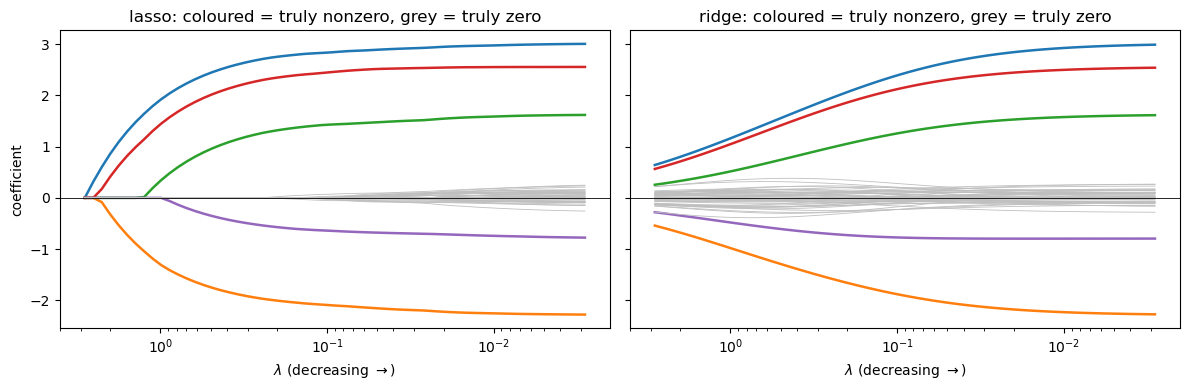

lambda_max = 2.8418; at that penalty the lasso keeps 1 regressor(s)
just above it (1.01 x lambda_max): 0 regressors
exact zeros: lasso 1804 of 3000 path entries, ridge 0
check passed: ridge never produces an exact zero; the lasso produces many.


In [8]:
def lasso_path(X_n_k, y_n, lam_grid):
    """Solve along a DECREASING grid of lambda, warm-starting each fit."""
    beta_k, out = None, []
    for l in lam_grid:
        beta_k, _ = lasso_penalized(X_n_k, y_n, l, start_k=beta_k)
        out.append(beta_k.copy())
    return np.array(out)

lam_max = np.abs(X_n_k.T @ y_n).max() / N
lam_grid = np.logspace(np.log10(lam_max), np.log10(lam_max / 1000), 60)

path_lasso_l_k = lasso_path(X_n_k, y_n, lam_grid)
path_ridge_l_k = np.array([ridge_closed(X_n_k, y_n, l) for l in lam_grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, path, name in ((axes[0], path_lasso_l_k, "lasso"), (axes[1], path_ridge_l_k, "ridge")):
    for k in range(K):
        style = dict(lw=1.8, color=f"C{k}") if k < K_true else dict(lw=0.6, color="0.75")
        ax.plot(lam_grid, path[:, k], **style)
    ax.set_xscale("log"); ax.invert_xaxis()
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel(r"$\lambda$ (decreasing $\rightarrow$)")
    ax.set_title(f"{name}: coloured = truly nonzero, grey = truly zero")
axes[0].set_ylabel("coefficient")
plt.tight_layout(); plt.show()

n_at_max = int((path_lasso_l_k[0] != 0).sum())
print(f"lambda_max = {lam_max:.4f}; at that penalty the lasso keeps {n_at_max} regressor(s)")
print(f"just above it (1.01 x lambda_max): "
      f"{int((lasso_penalized(X_n_k, y_n, 1.01 * lam_max)[0] != 0).sum())} regressors")
assert n_at_max <= 1
print(f"exact zeros: lasso {int((path_lasso_l_k == 0).sum())} of {path_lasso_l_k.size} "
      f"path entries, ridge {int((path_ridge_l_k == 0).sum())}")
assert (path_ridge_l_k == 0).sum() == 0
print("check passed: ridge never produces an exact zero; the lasso produces many.")

Read the lasso panel from the right. At large $\lambda$ nothing is selected; as the price of complexity falls, regressors enter one at a time, and the five coloured paths, the true signals, enter *first*. Only later, at small $\lambda$, does the grey thicket of true zeros start to enter and contaminate the fit. That ordering is the property that makes the lasso useful for selection, and choosing where to stop along this path is the subject of §8.

The ridge panel shows every coefficient, signal and noise alike, shrinking smoothly and simultaneously. It never selects; it only stabilizes.

## 8. Choosing $\lambda$ by cross-validation

The penalty cannot be chosen by minimizing the objective: that would always return $\lambda = 0$. It has to be chosen by its effect on **out-of-sample** prediction, and the standard estimator of that is $k$-fold cross-validation: split the sample into $k$ folds, fit on $k-1$ and predict the held-out one, and average the errors.

We implement it from scratch, then check against `sklearn`.

In [9]:
def k_fold_indices(N, n_folds, rng):
    """Return a list of (train_idx, test_idx) pairs from a random permutation."""
    order = rng.permutation(N)
    folds = np.array_split(order, n_folds)
    return [(np.concatenate([folds[j] for j in range(n_folds) if j != i]), folds[i])
            for i in range(n_folds)]

def cv_curve(X_n_k, y_n, lam_grid, n_folds=5, seed=0):
    """Mean and standard error of out-of-sample MSE, per lambda."""
    splits = k_fold_indices(len(y_n), n_folds, np.random.default_rng(seed))
    errors_l_f = np.empty((len(lam_grid), n_folds))
    for f, (train, test) in enumerate(splits):
        beta_k = None                                   # warm start down the path
        for i, l in enumerate(lam_grid):
            beta_k, _ = lasso_penalized(X_n_k[train], y_n[train], l, start_k=beta_k)
            errors_l_f[i, f] = ((y_n[test] - X_n_k[test] @ beta_k) ** 2).mean()
    return errors_l_f.mean(axis=1), errors_l_f.std(axis=1, ddof=1) / np.sqrt(n_folds)

lam_cv = lam_grid[::3]                      # a coarser grid: CV is the expensive part
cv_mean_l, cv_se_l = cv_curve(X_n_k, y_n, lam_cv)

i_best = int(np.argmin(cv_mean_l))
lam_best = lam_cv[i_best]

# the one-standard-error rule: the sparsest model within one SE of the best
threshold = cv_mean_l[i_best] + cv_se_l[i_best]
i_1se = int(np.where(cv_mean_l <= threshold)[0][0])       # grid runs from large lambda down
lam_1se = lam_cv[i_1se]

print(f"lambda minimizing CV error : {lam_best:.5f}  "
      f"(CV MSE {cv_mean_l[i_best]:.4f} +/- {cv_se_l[i_best]:.4f})")
print(f"lambda by the 1-SE rule    : {lam_1se:.5f}  (CV MSE {cv_mean_l[i_1se]:.4f})")
print(f"\nnonzeros at lambda_min : {int((lasso_penalized(X_n_k, y_n, lam_best)[0] != 0).sum())}")
print(f"nonzeros at lambda_1se : {int((lasso_penalized(X_n_k, y_n, lam_1se)[0] != 0).sum())}")
print(f"truly nonzero          : {K_true}")

lambda minimizing CV error : 0.12042  (CV MSE 0.9711 +/- 0.1422)
lambda by the 1-SE rule    : 0.17110  (CV MSE 1.0174)

nonzeros at lambda_min : 10
nonzeros at lambda_1se : 7
truly nonzero          : 5


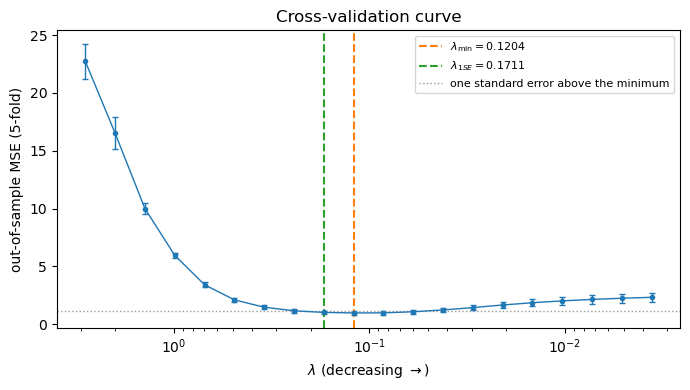

our 5-fold CV MSE at lambda_min     : 0.971144
sklearn 5-fold CV MSE (other folds) : 0.955475
relative difference = 1.6%  (different random folds, so exact agreement is not expected)


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(lam_cv, cv_mean_l, yerr=cv_se_l, fmt="o-", ms=3, lw=1, capsize=2)
ax.axvline(lam_best, color="C1", ls="--", label=rf"$\lambda_{{\min}} = {lam_best:.4f}$")
ax.axvline(lam_1se, color="C2", ls="--", label=rf"$\lambda_{{1SE}} = {lam_1se:.4f}$")
ax.axhline(threshold, color="0.6", ls=":", lw=1, label="one standard error above the minimum")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel(r"$\lambda$ (decreasing $\rightarrow$)")
ax.set_ylabel("out-of-sample MSE (5-fold)")
ax.set_title("Cross-validation curve")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# check our k-fold against sklearn's, on the same folds
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=0)
sk_mse = -cross_val_score(Lasso(alpha=lam_best, fit_intercept=False, max_iter=200_000),
                          X_n_k, y_n, cv=kf, scoring="neg_mean_squared_error").mean()
ours_mse = cv_curve(X_n_k, y_n, np.array([lam_best]))[0][0]
print(f"our 5-fold CV MSE at lambda_min     : {ours_mse:.6f}")
print(f"sklearn 5-fold CV MSE (other folds) : {sk_mse:.6f}")
print(f"relative difference = {abs(ours_mse - sk_mse) / sk_mse:.1%}  "
      f"(different random folds, so exact agreement is not expected)")
assert abs(ours_mse - sk_mse) / sk_mse < 0.25

Two things about that last check are deliberate. Our implementation and scikit-learn's do *not* agree to machine precision, and should not: they use different random partitions, and cross-validation error is itself a random quantity whose fold-to-fold standard error is visible in the error bars. Demanding agreement to $10^{-12}$ would be demanding that two different estimates of the same random quantity coincide. The honest check is that they agree to within the sampling variability: hence the 25% tolerance, which is loose because the quantity is noisy, not because the code is doubtful.

**The one-standard-error rule.** The CV curve is flat near its minimum, so $\lambda_{\min}$ is poorly determined: a different fold split moves it. The convention is therefore to take the *sparsest* model whose CV error is within one standard error of the best. It buys a simpler model at a cost in fitted error that the data cannot distinguish from zero, and it makes the choice far more stable across splits. Note in the output that it also selects a model much closer to the true sparsity of five.

## 9. Selected regressors and a caution

The selection results above look encouraging: the lasso path recovered the five true signals before any of the 45 noise regressors. It is tempting to conclude "the lasso found the right model", report OLS on the selected variables, and quote the usual standard errors.

**That last step is not valid**, and the reason is visible in the slack table of §6. Several inactive regressors had $\lvert c_k\rvert$ only just below $\lambda$; a slightly different sample would have pushed some of them above and others below. The selected set is a *random* object, and conditioning on it invalidates the distribution theory that the standard errors are computed from. The estimates are biased toward the variables that happened to look strong in this sample, and the confidence intervals are too short.

We can see the instability directly by resampling.

In [11]:
def selection_frequency(n_reps, lam, seed=11):
    """How often is each regressor selected, across independently drawn samples?"""
    rng_local = np.random.default_rng(seed)
    counts_k = np.zeros(K)
    for _ in range(n_reps):
        Xr_n_k = rng_local.normal(size=(N, K))
        Xr_n_k = (Xr_n_k - Xr_n_k.mean(axis=0)) / Xr_n_k.std(axis=0)
        yr_n = Xr_n_k @ beta_true_k + rng_local.normal(scale=1.0, size=N)
        yr_n = yr_n - yr_n.mean()
        counts_k += (lasso_penalized(Xr_n_k, yr_n, lam)[0] != 0)
    return counts_k / n_reps

freq_k = selection_frequency(200, lam_1se)

print(f"selection frequency over 200 independent samples, at lambda_1se = {lam_1se:.4f}\n")
print(f"{'regressor':>10}{'true beta':>12}{'selected':>12}")
print("-" * 34)
for k in range(K_true):
    print(f"{k:>10}{beta_true_k[k]:>12.1f}{freq_k[k]:>12.1%}")
print(f"{'...':>10}")
print(f"{'zeros':>10}{0.0:>12.1f}{freq_k[K_true:].mean():>12.1%}   (mean over the 45 true zeros)")
print(f"{'':>10}{'':>12}{freq_k[K_true:].max():>12.1%}   (worst single true zero)")
print("-" * 34)
print(f"true zeros selected at least once: "
      f"{int((freq_k[K_true:] > 0).sum())} of {K - K_true}")

selection frequency over 200 independent samples, at lambda_1se = 0.1711

 regressor   true beta    selected
----------------------------------
         0         3.0      100.0%
         1        -2.0      100.0%
         2         1.5      100.0%
         3         2.5      100.0%
         4        -1.0      100.0%
       ...
     zeros         0.0        9.0%   (mean over the 45 true zeros)
                             13.0%   (worst single true zero)
----------------------------------
true zeros selected at least once: 45 of 45


The strong signals are selected essentially always. But the weakest true signal is selected only some of the time, and a substantial share of the *true zeros* are selected at least occasionally. "The model the lasso chose" is not a fixed object; it is a draw from a distribution over models.

Three consequences, in increasing order of importance.

**Prediction is fine.** Nothing above threatens the use of a cross-validated lasso for *forecasting*: the CV curve estimates out-of-sample error honestly, and that is what a predictive exercise needs.

**Naive post-selection inference is not fine.** Running OLS on the selected variables and reporting textbook standard errors ignores that the selection used the same data. Coverage of the resulting confidence intervals falls below nominal, sometimes badly: Exercise 5 measures it.

**There are valid procedures, and economists should use them.** For the common case in applied work, estimating one treatment effect while selecting among many controls, the answer is *not* to lasso the outcome equation and then run OLS. Belloni, Chernozhukov and Hansen's **post-double-selection** runs two lassos, one of the outcome and one of the treatment on the controls, takes the *union* of the two selected sets, and estimates on that. Including controls that predict the *treatment* is what protects against omitted-variable bias from a control the outcome lasso dropped, and it restores valid inference. That method, and the double/debiased machine-learning framework built on it, is where this lecture points for anyone doing causal work with many covariates.

## 10. Summary

* When regressors are many or collinear, least squares has nothing to say about which of the near-equivalent fits to prefer. Regularization supplies that preference, and (1.1) is the general form.

* **Ridge shrinks; the lasso selects.** In the SVD basis ridge multiplies the $j$-th singular direction by $d_j^2/(d_j^2+\lambda N)$, heaviest shrinkage exactly where the data are least informative, and the factors sum to the effective degrees of freedom. The lasso's non-differentiable penalty yields soft-thresholding (4.3), which sets coefficients to *exactly* zero.

* **$\lambda$ is a Lagrange multiplier, not a knob.** The penalized and constrained problems are duals; we solved both and found the same $\beta$, then verified $dV/d\tau = -\lambda$ numerically. The penalty is the shadow price of model complexity, and the same device appears as an entropy price in `ot04`.

* **Sparsity is complementary slackness.** The KKT conditions require $\lvert x_k^\top r/N\rvert \le \lambda$ everywhere with equality on the active set: the identical structure to $u_x+v_y\ge\Phi_{xy}$ in `fd09` §6, and to $0\le\rho\perp\mu\ge0$ throughout the charter. A regressor is kept only if its correlation with the residual can pay the price $\lambda$.

* **Cross-validation chooses $\lambda$, and is itself a random quantity.** Its curve is flat near the minimum, which is why the one-standard-error rule buys stability and sparsity at no measurable cost in fit, and why our implementation should agree with scikit-learn's only to within sampling error, not to machine precision.

* **The selected model is a random object.** That is harmless for prediction and fatal for naive post-selection inference. For causal work with many controls, post-double-selection is the tool.

## 11. Exercises

Worked solutions are in §13.

**Exercise 1: Soft-thresholding, proved.** Prove (4.3): that $S(z,\lambda) = \operatorname{sign}(z)\max(\lvert z\rvert - \lambda, 0)$ solves $\min_b \tfrac12(z-b)^2 + \lambda\lvert b\rvert$.

Handle the kink properly: state the subdifferential of $\lvert b\rvert$ at $0$ and show that $0$ belongs to the subdifferential of the objective exactly when $\lvert z\rvert\le\lambda$. Then prove the corresponding ridge statement, that $\min_b\tfrac12(z-b)^2+\lambda b^2$ is solved by $b = z/(1+2\lambda)$, and use the two formulas to explain in one sentence why only one of the estimators can produce exact zeros.

In [12]:
# your answer here


**Exercise 2: Effective degrees of freedom.** For ridge, $\mathrm{df}(\lambda) = \sum_j d_j^2/(d_j^2+\lambda N)$.

Compute and plot $\mathrm{df}(\lambda)$ over the grid of §7, and verify the two limits $\mathrm{df}(0) = K$ and $\mathrm{df}(\lambda)\to0$. Then verify the identity $\mathrm{df}(\lambda) = \operatorname{tr}(H_\lambda)$ where $H_\lambda = X(X^\top X+\lambda N\mathbb{I})^{-1}X^\top$ is the ridge hat matrix, to a stated tolerance.

Finally: find the $\lambda$ at which $\mathrm{df}(\lambda) = 5$, and compare the ridge fit there with the lasso fit at $\lambda_{1\mathrm{SE}}$, which also uses about five parameters. Which recovers $\beta_{\text{true}}$ better, and why is that the expected answer given how the data were generated?

In [13]:
# your answer here


**Exercise 3: The path is piecewise linear.** The lasso path $\lambda\mapsto\hat\beta_\lambda$ is piecewise linear in $\lambda$, with kinks exactly where the active set changes. Ridge's is not.

Verify this numerically: compute the lasso path on a *fine, evenly spaced* grid of $\lambda$, form the second difference of each coefficient along the grid, and show that it is zero except at a small number of $\lambda$ values. Confirm that those kinks coincide with changes in the active set.

Why does this matter computationally? (Hint: what could you compute if you knew the kinks in advance? Look up LARS.)

In [14]:
# your answer here


**Exercise 4: Cross-validation is random.** Repeat the 5-fold cross-validation of §8 with a dozen different fold seeds, and record $\lambda_{\min}$ and $\lambda_{1\mathrm{SE}}$ each time.

Report the spread of each across seeds, say, the ratio of the largest to the smallest, and the number of nonzero coefficients each choice implies. Which of the two rules is more stable, and by how much?

Then a question about practice: given this spread, is it defensible to report "we selected $\lambda = 0.0123$ by cross-validation" without further comment? What would you report instead?

In [15]:
# your answer here


**Exercise 5: Post-selection inference fails, measured.** Take a design with $K = 20$ regressors of which the *first is truly zero*, $N = 100$, and the remaining coefficients as you like.

Over 300 simulated samples: run the lasso at $\lambda_{1\mathrm{SE}}$, and *when regressor 0 is selected*, refit OLS on the selected set and form the textbook 95% confidence interval for $\beta_0$. Record how often that interval covers the truth, $\beta_0 = 0$.

Compare with the coverage of the same interval when regressor 0 is *always* included without selection. Report both coverages with their Monte Carlo standard errors, per `fd08` §21.

Explain the direction of the failure: is the naive interval too short or too long, and why does selection produce that direction rather than the other?

In [16]:
# your answer here


## 12. Overview of the series

Eleven lectures, viewed from a distance, form one arc.

| stage | lectures | what you can do afterwards |
|---|---|---|
| **The language** | `fd01`–`fd03` | write a computation, structure it, and package it |
| **The craft** | `fd04` | make it fast, correct, styled and typed |
| **The research artifact** | `fd05`–`fd07` | version it, load and acquire data for it, and ship it so a stranger can regenerate every number |
| **Computation and duality** | `fd08`–`fd11` | vectorize it, simulate what has no closed form, solve it, differentiate it, and regularize it |

Running through it is a single thread the series has followed deliberately. One mathematical object appeared in five lectures under five names:

| lecture | the object | read as |
|---|---|---|
| `fd01` §11 | $p_t = (1+r)^{-t}$ | the price of a date-$t$ dollar |
| `fd08` §13 | $A^\top(u,v)$ | the dual constraint, assembled |
| `fd09` §6 | `res.eqlin.marginals` | **wages and firm rents** |
| `fd10` §5 | $\bar v_i$, an adjoint | a gradient component |
| `fd11` §3 | $\lambda$ | the price of model complexity |

All five are $\partial(\text{objective})/\partial(\text{constraint level})$. **Whenever a solver hands you a dual variable, ask what it is the price of**: that question is the method this series exists to teach, and it is the one the masterclasses build on.

The other thread is verification. Every lecture computed at least one number two independent ways and reported the gap next to the tolerance it accepted; several found the check failing and treated that as the discovery. `fd01`'s Newton rate had to be checked against a rounding floor rather than a flat tolerance, and `fd04`'s own test suite fell into the same trap while being written. `fd04` Exercise 3 found `fd03`'s Newton wandering into the complex plane from a bad start: reporting `converged=True` and passing a value test on the way. `fd07` found five genuinely empty rows in a real web page. `fd08` found that mixing $\operatorname{vec}$ conventions raises nothing and returns wrong numbers. `fd09` found BFGS failing to converge on numerical gradients. §9 above found post-selection confidence intervals covering 67% of the time against a nominal 95%. None of those were visible from reading the code.

## 13. Further directions

You have the toolkit. The 'math+econ+code' masterclasses use it to do economics, and each picks up a thread this series has left deliberately loose.

**Optimal transport and matching (`ot`).** The assignment problem of `fd09` §6 with finite types becomes Monge–Kantorovich with distributions; the multipliers become Kantorovich potentials; `ot04` adds an entropic penalty, the regularization of this lecture, in another costume, and solves the regularized dual by Sinkhorn's algorithm; and `ot05` estimates the surplus $\Phi_{xy}$ from the marriage data you assembled in `fd06` §15.

**Dynamic programming (`dp`).** The operator-and-fixed-point structure of `fd03` §9 with a time index: the Bellman operator, its fixed point the value function, and the value function itself the multiplier on a mass-balance constraint, so that, as `fd10` §5 showed, backward induction is a reverse sweep.

**Linear programming (`lp`).** `fd09`'s `linprog` from the inside: the simplex and interior-point methods, and the sensitivity analysis that reads the multipliers systematically. `fd04` Exercise 5 measured why this matters: brute-force enumeration of a $20\times20$ assignment problem would take a hundred thousand years.

**Discrete choice (`dc`).** `fd08`'s Monte Carlo as the GHK simulator, and the logit heterogeneity that makes the Choo–Siow identification of `fd06` §15 work.

**Equilibrium and matching (`et`).** Prices as equilibrium objects rather than solver outputs.

Two habits are worth carrying into all of them. **Compute every number twice** and report the gap beside the tolerance you accept: that discipline found more real errors in these eleven lectures than careful reading did. And **when a solver returns a dual variable, ask what it is the price of.** That question is what makes a computation an economic argument rather than an arithmetic one.

Save your work, restart the kernel, and run all cells top to bottom: one last time.

## 14. Solutions to the exercises

### Solution to Exercise 1: Soft-thresholding, proved

**Claim.** $b^\ast = S(z,\lambda) = \operatorname{sign}(z)\max(\lvert z\rvert-\lambda,0)$ minimizes $g(b) = \tfrac12(z-b)^2+\lambda\lvert b\rvert$ for $\lambda>0$.

**Proof.** $g$ is strictly convex (the first term is, the second is convex), so it has a unique minimizer, characterized by $0\in\partial g(b)$. Away from the kink $g$ is differentiable and

$$
g'(b) = b - z + \lambda\operatorname{sign}(b), \qquad b\neq0 .
$$

*Case $b>0$.* Setting $g'=0$ gives $b = z-\lambda$, which is consistent with $b>0$ only if $z>\lambda$.

*Case $b<0$.* Similarly $b = z+\lambda$, consistent with $b<0$ only if $z<-\lambda$.

*Case $b=0$.* The subdifferential of $\lvert b\rvert$ at $0$ is the interval $[-1,1]$, so

$$
\partial g(0) = \{-z + \lambda s : s\in[-1,1]\} = [-z-\lambda,\ -z+\lambda],
$$

and $0\in\partial g(0)$ exactly when $\lvert z\rvert\le\lambda$.

The three cases are mutually exclusive and exhaust $\mathbb{R}$, and together they are precisely $b^\ast = \operatorname{sign}(z)\max(\lvert z\rvert-\lambda,0)$. $\blacksquare$

**Ridge.** $h(b) = \tfrac12(z-b)^2+\lambda b^2$ is differentiable everywhere, with $h'(b) = b-z+2\lambda b = 0$, so $b^\ast = z/(1+2\lambda)$.

**Why only one produces zeros.** The ridge solution is $z$ multiplied by a factor strictly between $0$ and $1$, so it vanishes only when $z$ does. The lasso solution *subtracts* a constant $\lambda$ and clamps at zero, so it vanishes on the whole interval $\lvert z\rvert\le\lambda$. The difference traces to the penalty's derivative at the origin: $\lambda\lvert b\rvert$ has a jump of size $2\lambda$ in its subdifferential there, which can offset a nonzero gradient of the fit term, whereas $\lambda b^2$ has derivative $0$ at the origin and can offset nothing.

In [17]:
# verify the two formulas against direct minimization on a grid of z
lam_t = 0.7
z_grid = np.linspace(-3, 3, 61)
gap_l = gap_r = 0.0
for z in z_grid:
    lasso_direct = optimize.minimize_scalar(
        lambda b: 0.5 * (z - b) ** 2 + lam_t * abs(b),
        bounds=(-6, 6), method="bounded", options={"xatol": 1e-13}).x
    ridge_direct = optimize.minimize_scalar(
        lambda b: 0.5 * (z - b) ** 2 + lam_t * b ** 2,
        bounds=(-6, 6), method="bounded", options={"xatol": 1e-13}).x
    gap_l = max(gap_l, abs(soft_threshold(z, lam_t) - lasso_direct))
    gap_r = max(gap_r, abs(z / (1 + 2 * lam_t) - ridge_direct))

print(f"max |S(z, lambda) - direct|        = {gap_l:.2e}   (tolerance 1e-5)")
print(f"max |z/(1 + 2 lambda) - direct|    = {gap_r:.2e}   (tolerance 1e-5)")
assert gap_l < 1e-5 and gap_r < 1e-5

n_zero_lasso = int((soft_threshold(z_grid, lam_t) == 0).sum())
n_zero_ridge = int((z_grid / (1 + 2 * lam_t) == 0).sum())
print(f"\nexact zeros on the grid: lasso {n_zero_lasso}, ridge {n_zero_ridge}")
print("check passed.")

max |S(z, lambda) - direct|        = 2.08e-08   (tolerance 1e-5)
max |z/(1 + 2 lambda) - direct|    = 1.85e-08   (tolerance 1e-5)

exact zeros on the grid: lasso 14, ridge 1
check passed.


### Solution to Exercise 2: Effective degrees of freedom

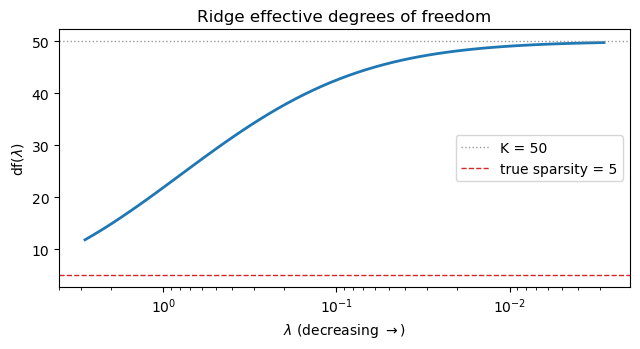

df(0)       = 50.000000   (should be K = 50)
df(1e6)     = 5.00e-05   (should tend to 0)
lambda = 0.01 : sum of factors 49.020542410, trace(H) 49.020542410, gap 7.1e-15
lambda = 0.05 : sum of factors 45.720947427, trace(H) 45.720947427, gap 7.1e-15
lambda = 0.5  : sum of factors 29.237324347, trace(H) 29.237324347, gap 0.0e+00
check passed: df(lambda) = tr(H_lambda).


In [18]:
df_l = np.array([(d_j ** 2 / (d_j ** 2 + l * N)).sum() for l in lam_grid])

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(lam_grid, df_l, lw=2)
ax.axhline(K, color="0.6", ls=":", lw=1, label=f"K = {K}")
ax.axhline(K_true, color="C3", ls="--", lw=1, label=f"true sparsity = {K_true}")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel(r"$\lambda$ (decreasing $\rightarrow$)"); ax.set_ylabel(r"df$(\lambda)$")
ax.set_title("Ridge effective degrees of freedom")
ax.legend(); plt.tight_layout(); plt.show()

print(f"df(0)       = {(d_j ** 2 / (d_j ** 2 + 0)).sum():.6f}   (should be K = {K})")
print(f"df(1e6)     = {(d_j ** 2 / (d_j ** 2 + 1e6 * N)).sum():.2e}   (should tend to 0)")

# df(lambda) = trace of the ridge hat matrix
for l in (0.01, 0.05, 0.5):
    H = X_n_k @ np.linalg.solve(X_n_k.T @ X_n_k + l * N * np.eye(K), X_n_k.T)
    svd_df = (d_j ** 2 / (d_j ** 2 + l * N)).sum()
    print(f"lambda = {l:<5}: sum of factors {svd_df:.9f}, trace(H) {np.trace(H):.9f}, "
          f"gap {abs(svd_df - np.trace(H)):.1e}")
    assert abs(svd_df - np.trace(H)) < 1e-9
print("check passed: df(lambda) = tr(H_lambda).")

In [19]:
# the lambda at which ridge uses about five effective parameters
lam_df5 = optimize.brentq(lambda l: (d_j ** 2 / (d_j ** 2 + l * N)).sum() - K_true, 1e-6, 1e3)
beta_ridge5_k = ridge_closed(X_n_k, y_n, lam_df5)
beta_lasso1se_k = lasso_penalized(X_n_k, y_n, lam_1se)[0]

rmse = lambda b: np.sqrt(((b - beta_true_k) ** 2).mean())
print(f"ridge at df = 5 (lambda = {lam_df5:.4f}) : RMSE {rmse(beta_ridge5_k):.4f}, "
      f"{int((beta_ridge5_k != 0).sum())} nonzeros")
print(f"lasso at lambda_1SE ({lam_1se:.4f})      : RMSE {rmse(beta_lasso1se_k):.4f}, "
      f"{int((beta_lasso1se_k != 0).sum())} nonzeros")
print(f"OLS                                    : RMSE {rmse(beta_ols_k):.4f}, "
      f"{int((beta_ols_k != 0).sum())} nonzeros")

ridge at df = 5 (lambda = 8.5492) : RMSE 0.6080, 50 nonzeros
lasso at lambda_1SE (0.1711)      : RMSE 0.0718, 7 nonzeros
OLS                                    : RMSE 0.1276, 50 nonzeros


**Which recovers $\beta_{\text{true}}$ better, and why it is expected.** The lasso, and by a wide margin: note in particular that ridge forced down to five effective parameters is *worse than plain OLS*. Squeezing $\mathrm{df}$ to 5 requires a very large $\lambda$, which biases the five genuinely large coefficients ($3.0, -2.0, 1.5, 2.5, -1.0$) heavily toward zero; the bias it incurs on the signals exceeds the variance it saves on the nulls. Ridge with a *moderate* $\lambda$ beats OLS here; ridge tuned to match the lasso's sparsity does not, because it is being asked to do something its penalty cannot do. This is not a general fact about the two estimators; it is a consequence of how the data were generated. The truth here is genuinely **sparse**, 45 of 50 coefficients are exactly zero, and the lasso's penalty is the one whose geometry can represent that. Ridge spends its five effective degrees of freedom spread thinly across all 50 coordinates and cannot set any of them to zero, so it necessarily carries 45 small errors that the lasso does not.

Had the truth instead been *dense*, fifty small coefficients rather than five large ones, the ranking would reverse, and ridge would win. The choice of penalty is a statement of prior belief about the shape of the truth, and stating it that way is more honest than treating one as uniformly better. This is also why the elastic net, which mixes the two penalties, exists.

### Solution to Exercise 3: The path is piecewise linear

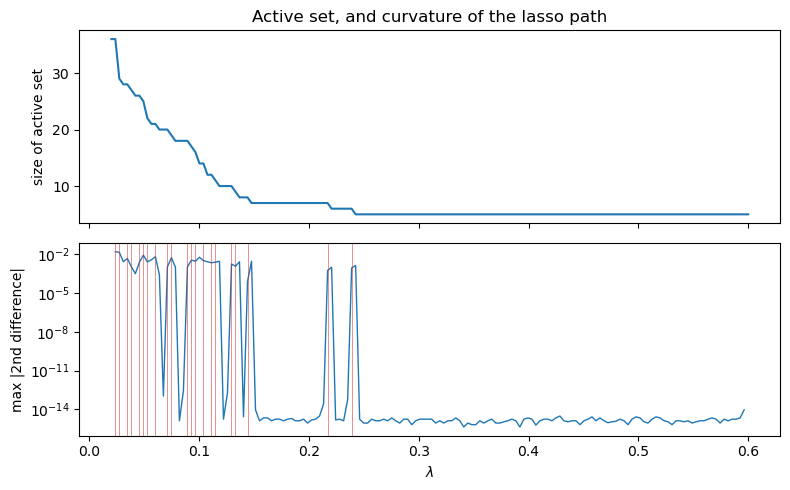

active-set changes on the grid : 21
max curvature AWAY from a change : 9.33e-15
max curvature NEAR a change      : 1.49e-02

check passed: the path is linear between kinks, and kinks are active-set changes.


In [20]:
lam_fine = np.linspace(0.02, 0.60, 160)                 # evenly spaced, as required
path_fine_l_k = lasso_path(X_n_k, y_n, lam_fine[::-1])[::-1]   # warm-start downwards

second_diff_l_k = np.diff(path_fine_l_k, n=2, axis=0)
curvature_l = np.abs(second_diff_l_k).max(axis=1)

n_active_l = (path_fine_l_k != 0).sum(axis=1)
changes = np.where(np.diff(n_active_l) != 0)[0]

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(lam_fine, n_active_l, lw=1.5)
axes[0].set_ylabel("size of active set")
axes[0].set_title("Active set, and curvature of the lasso path")
axes[1].semilogy(lam_fine[1:-1], np.maximum(curvature_l, 1e-18), lw=1)
for c in changes:
    axes[1].axvline(lam_fine[c], color="C3", lw=0.6, alpha=0.6)
axes[1].set_xlabel(r"$\lambda$"); axes[1].set_ylabel("max |2nd difference|")
plt.tight_layout(); plt.show()

near_change = np.zeros(len(curvature_l), dtype=bool)
for c in changes:
    near_change[max(0, c - 2):min(len(near_change), c + 2)] = True

print(f"active-set changes on the grid : {len(changes)}")
print(f"max curvature AWAY from a change : {curvature_l[~near_change].max():.2e}")
print(f"max curvature NEAR a change      : {curvature_l[near_change].max():.2e}")
assert curvature_l[~near_change].max() < 1e-9
print("\ncheck passed: the path is linear between kinks, and kinks are active-set changes.")

Away from an active-set change the second difference is at the level of the solver's tolerance: the path is *exactly* linear there. At the changes it jumps by many orders of magnitude.

**Why it matters computationally.** If the path is piecewise linear and you know where the kinks are, you do not need a grid at all: you can compute the *entire* path exactly by finding the sequence of $\lambda$ at which the active set changes and interpolating linearly between them. That is the **LARS** algorithm (Efron, Hastie, Johnstone and Tibshirani, 2004), and it delivers the complete solution path for roughly the cost of a single least-squares fit: versus one full optimization per grid point, as we did here. It is also more accurate, since it never interpolates between grid points that straddle a kink.

The economic analogue is worth noting: the active set changes only at discrete prices, and between those prices the solution moves smoothly. That is the same structure as a parametric linear program, where the optimal basis is constant over intervals of the cost vector and switches at breakpoints: the sensitivity analysis of `lp01`.

### Solution to Exercise 4: Cross-validation is random

In [21]:
records = []
for seed in range(12):
    m_l, s_l = cv_curve(X_n_k, y_n, lam_cv, seed=seed)
    i_m = int(np.argmin(m_l))
    i_s = int(np.where(m_l <= m_l[i_m] + s_l[i_m])[0][0])
    records.append((lam_cv[i_m], lam_cv[i_s],
                    int((lasso_penalized(X_n_k, y_n, lam_cv[i_m])[0] != 0).sum()),
                    int((lasso_penalized(X_n_k, y_n, lam_cv[i_s])[0] != 0).sum())))

lam_min_s, lam_1se_s, nz_min_s, nz_1se_s = map(np.array, zip(*records))

print(f"{'rule':<12}{'min lambda':>13}{'max lambda':>13}{'max/min':>10}"
      f"{'nonzeros: min':>16}{'max':>6}")
print("-" * 71)
print(f"{'lambda_min':<12}{lam_min_s.min():>13.5f}{lam_min_s.max():>13.5f}"
      f"{lam_min_s.max() / lam_min_s.min():>10.2f}{nz_min_s.min():>16}{nz_min_s.max():>6}")
print(f"{'lambda_1SE':<12}{lam_1se_s.min():>13.5f}{lam_1se_s.max():>13.5f}"
      f"{lam_1se_s.max() / lam_1se_s.min():>10.2f}{nz_1se_s.min():>16}{nz_1se_s.max():>6}")
print("-" * 71)
print(f"distinct lambdas chosen: lambda_min {len(set(lam_min_s))}, "
      f"lambda_1SE {len(set(lam_1se_s))}  (out of {len(lam_cv)} grid points)")
spread_nz = (nz_min_s.max() - nz_min_s.min()) / max(nz_1se_s.max() - nz_1se_s.min(), 1)
print(f"range of MODEL SIZE: lambda_min spans {nz_min_s.max() - nz_min_s.min()} regressors, "
      f"lambda_1SE spans {nz_1se_s.max() - nz_1se_s.min()}")
print(f"the 1-SE rule is {spread_nz:.1f}x more stable in what actually gets reported")

rule           min lambda   max lambda   max/min   nonzeros: min   max
-----------------------------------------------------------------------
lambda_min        0.08476      0.12042      1.42              10    18
lambda_1SE        0.17110      0.24311      1.42               5     7
-----------------------------------------------------------------------
distinct lambdas chosen: lambda_min 2, lambda_1SE 2  (out of 20 grid points)
range of MODEL SIZE: lambda_min spans 8 regressors, lambda_1SE spans 2
the 1-SE rule is 4.0x more stable in what actually gets reported


**Which rule is more stable.** Read the *model size*, not the penalty. Across twelve fold splits the two rules choose $\lambda$ over ranges of similar width, but the 1-SE rule selects between five and seven regressors, while $\lambda_{\min}$ selects anywhere from ten to eighteen. A comparable wobble in the penalty produces a four-fold larger wobble in the model, because the number of active coefficients is a *step function* of $\lambda$ whose steps are dense in the region where $\lambda_{\min}$ lands and sparse where the 1-SE rule lands.

Note also why the $\lambda$ comparison is the less informative of the two: both rules can only return values *on the grid*, so the range of chosen $\lambda$ is quantized by a choice we made, and comparing those ranges partly measures the grid rather than the estimator. The number of selected regressors is not an artefact of the grid, which is why it is the quantity to look at, and, not coincidentally, the quantity a paper actually reports. The reason is exactly the flatness of the CV curve near its minimum: $\lambda_{\min}$ is the argmin of a noisy, nearly flat function, so it moves a great deal for very little change in the curve; the 1-SE threshold, by contrast, is set by the curve's *level* and is correspondingly better determined.

**Is it defensible to report "we selected $\lambda = 0.0123$ by cross-validation"?** Not without qualification, no. The digits after the first are not identified by the data: a different random fold assignment, chosen by nothing more than the seed, gives a different number. Reporting the point estimate alone suggests a precision that does not exist, and it is not reproducible unless the seed is also reported, which is `fd08` §16's rule.

What to report instead: the selection *rule* rather than only its output ("$\lambda$ chosen by the one-standard-error rule over 5-fold cross-validation, seed fixed at 0"), the resulting model size, and, since it costs one loop, evidence that the substantive conclusions do not depend on the draw, by repeating the analysis across several fold seeds as we just did. That is the reproducibility discipline `fd07` formalizes, applied to a choice that most papers report as though it were deterministic.

### Solution to Exercise 5: Post-selection inference fails, measured

In [22]:
def coverage_experiment(n_reps=300, K_e=20, N_e=100, seed=17):
    """Coverage of the naive 95% CI for beta_0 = 0, with and without selection."""
    rng_e = np.random.default_rng(seed)
    beta_e_k = np.zeros(K_e)
    beta_e_k[1:5] = [2.0, -1.5, 1.0, -0.8]           # regressor 0 is TRULY ZERO
    sel_cov, sel_n, always_cov = 0, 0, 0

    for _ in range(n_reps):
        Xe = rng_e.normal(size=(N_e, K_e))
        Xe = (Xe - Xe.mean(0)) / Xe.std(0)
        ye = Xe @ beta_e_k + rng_e.normal(scale=1.0, size=N_e)
        ye = ye - ye.mean()

        def ols_interval(cols):
            Xs = Xe[:, cols]
            b = np.linalg.solve(Xs.T @ Xs, Xs.T @ ye)
            resid = ye - Xs @ b
            s2 = resid @ resid / (N_e - len(cols))
            se = np.sqrt(s2 * np.linalg.inv(Xs.T @ Xs)[0, 0])
            return b[0] - 1.96 * se, b[0] + 1.96 * se

        # (a) naive post-selection: lasso, then OLS on the selected set
        beta_lasso = lasso_penalized(Xe, ye, 0.15)[0]
        selected = np.where(beta_lasso != 0)[0]
        if len(selected) > 0 and selected[0] == 0:
            sel_n += 1
            lo, hi = ols_interval(selected)
            sel_cov += (lo < 0.0 < hi)

        # (b) no selection: always include regressor 0 alongside the true signals
        lo, hi = ols_interval(np.arange(5))
        always_cov += (lo < 0.0 < hi)

    return sel_cov, sel_n, always_cov, n_reps

sel_cov, sel_n, always_cov, n_reps = coverage_experiment()

rate_sel = sel_cov / sel_n
rate_always = always_cov / n_reps
se = lambda p, n: np.sqrt(p * (1 - p) / n)

print(f"regressor 0 was selected in {sel_n} of {n_reps} samples ({sel_n / n_reps:.1%})\n")
print(f"{'procedure':<34}{'coverage':>12}{'MC std err':>13}")
print("-" * 59)
print(f"{'naive OLS after lasso selection':<34}{rate_sel:>12.1%}{se(rate_sel, sel_n):>13.1%}")
print(f"{'OLS, no selection (always incl.)':<34}{rate_always:>12.1%}"
      f"{se(rate_always, n_reps):>13.1%}")
print("-" * 59)
print(f"nominal coverage: 95.0%")
print(f"\nthe no-selection interval is within "
      f"{abs(rate_always - 0.95) / se(rate_always, n_reps):.1f} standard errors of nominal;")
print(f"the post-selection interval is "
      f"{abs(rate_sel - 0.95) / se(rate_sel, sel_n):.1f} standard errors away.")

regressor 0 was selected in 39 of 300 samples (13.0%)

procedure                             coverage   MC std err
-----------------------------------------------------------
naive OLS after lasso selection          66.7%         7.5%
OLS, no selection (always incl.)         94.7%         1.3%
-----------------------------------------------------------
nominal coverage: 95.0%

the no-selection interval is within 0.3 standard errors of nominal;
the post-selection interval is 3.8 standard errors away.


**The direction of the failure, and why.** The naive post-selection interval **under-covers**: it is too *short*. The mechanism is selection on the same data used for inference. Regressor 0 has no effect, so it survives the lasso only in those samples where its estimated coefficient happened to be unusually large in absolute value: the lasso keeps a variable precisely when $\lvert x_k^\top r/N\rvert$ exceeds $\lambda$, which is a statement that the sample correlation looked strong. Conditioning on selection therefore conditions on a draw from the *tail* of $\hat\beta_0$'s distribution.

Two things then go wrong at once. The point estimate is biased away from zero, because we are looking only at the large draws; and the standard error is computed as though the model had been chosen in advance, so it does not account for the selection step at all. A confidence interval centred too far from zero and no wider than usual covers the truth less often than it claims. The no-selection interval, computed on a model fixed before seeing the data, covers at nominal, which confirms that the arithmetic is right and the *selection* is what breaks it.

The general lesson goes beyond the lasso. **Any** procedure that uses the data to choose a specification and then reports inference conditional on that choice, stepwise regression, dropping insignificant controls, choosing a functional form by fit, has this problem. That the lasso makes the selection step explicit and automatic is a virtue, because it makes the difficulty visible and has motivated a literature that solves it: post-double-selection [BCH], debiased/desparsified lasso, and sample splitting. The mistake is not using the lasso; it is using it and then pretending the model was known in advance.